In [1]:
import os
import numpy as np

import darklim

from darklim.sensitivity._random_sampling import pdf_sampling

from scipy.special import factorial
import scipy.stats as stats
from scipy import integrate, interpolate

import matplotlib.pyplot as plt
if None != os.getenv('NERSC_HOST'):
    import matplotlib.font_manager as font_manager
    font_manager.fontManager.addfont('/global/cfs/cdirs/lz/physics/WS/SR1/msttcorefonts/Times_New_Roman.ttf')

import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
from multihist import Hist1d

%matplotlib inline

In [2]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

def find_nearest_floor(array, value):
    array = np.asarray(array)
    #idx = (np.floor(np.abs(array - value))).argmin()
    idx = array.searchsorted(value, 'right') - 1
    return idx, array[idx]

def pdf_integral(pdf,e_low,e_high,npts):
    '''
    assumes 'pdf' is a lambda function
    '''
    en_interp = np.geomspace(e_low,e_high, num=npts)
    return np.trapz( pdf(en_interp), x=en_interp)

def pile_up_rate_4fold(rate,window):
    return 4*rate**4 * window**(4-1)

def hist_integral(h,start,stop,option=None):
    """
    integrate (sum) bin content of histogram from
    in the (inclusive) interval [start,stop], where
    start and stop are given in data coordinates.
    """
    coordinates = np.array([start,stop])
    bin_edges = h.bin_edges
    bin_widths = h.bin_edges[1::]-h.bin_edges[:-1]
    index_array = np.clip(np.searchsorted(bin_edges, coordinates) - 1,
                              0,
                              len(bin_edges) - 2)
    if option==None:
        return np.sum(h.histogram[index_array[0]:index_array[1]+1])
    if option=='w': # multipy by bin width
        return np.sum(h.histogram[index_array[0]:index_array[1]+1] * bin_widths[index_array[0]:index_array[1]+1] )

def load_template(detector='4-1cm2',window='fixed',part='nopart',thres=0.8e-3,src='test'):
    
    basedir = '/global/cfs/cdirs/lz/users/haselsco/TESSERACT_Limits/DarkLim_vetriupdate/examples/Run57_LEE_templates_'+src+'/'
    fname = 'LEE_bkg_{:s}_{:s}_{:s}_{:0.2e}keV.txt'.format(detector,window,part,thres)
    template = np.loadtxt(basedir+fname,skiprows=1)

    e_low = thres*4 # lowest bin edge at lowest possible summed energy
    e_high = 1
    htemp = Hist1d.from_histogram(template[:,1],np.geomspace(e_low,e_high,num=len(template[:,1])+1))
    bw = htemp.bin_edges[1::]-htemp.bin_edges[:-1]
    
    return htemp
    

250
249


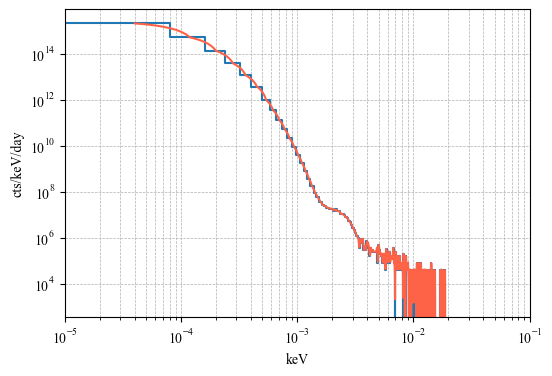

In [3]:
# Run57 load LEE histogram
si_mass_kg = 0.2329e-3

run57 = np.loadtxt('combined_spectra.txt')
bw = run57[1,0]-run57[0,0]
edges = np.append(run57[:,0]-bw/2,run57[-1,0]+bw/2)
edges[0] = 0.
print( len(edges) )
print( len(run57[:,1]) )

fig, ax = plt.subplots(1,figsize=(6,4))
h = Hist1d.from_histogram(run57[:,1]*si_mass_kg,edges)
h.plot()

ax.set_xlim(0.1e-4,1e-1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('cts/keV/day')
ax.set_xlabel('keV')

ax.grid(lw=0.5,ls='--',which='both')

# make interpolation function to use as well:
lee_func = interpolate.interp1d(h.bin_centers,h.histogram,bounds_error=False,fill_value=0)
e_low, e_high = h.bin_centers[0], 100e-3
en_interp = np.linspace(e_low,e_high, num=10000)
plt.plot(en_interp,lee_func(en_interp),color='tomato')

OG rate above 0.10eV:	 5.5362e+10 cts/day
converted rate above 0.10eV:	 5.5362e+10 cts/day


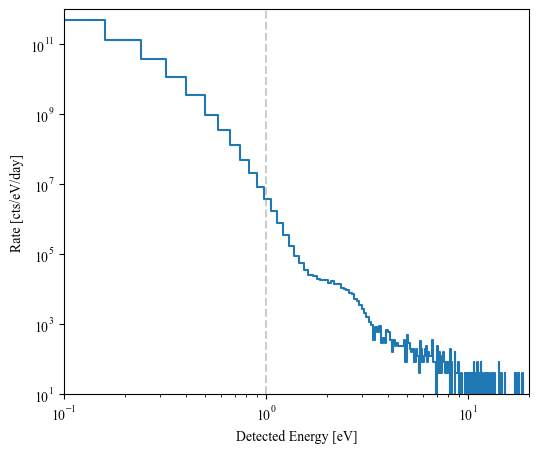

In [4]:
# function to convert 'per keV' histograms to 'per eV'
def convert_to_eV(h):
    hn = h.similar_blank_hist()
    hn.bin_edges *= 1e3
    hn.histogram = h.histogram/1e3
    return hn

hev = convert_to_eV(h)
fig, ax = plt.subplots(1,figsize=(6,5))
hev.plot()
ax.set_xlim(0.1,20)
ax.set_ylim(1e1,1e12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Rate [cts/eV/day]')
ax.set_xlabel('Detected Energy [eV]')
#ax.grid(lw=0.5,ls='--',which='both')

ax.axvline(1,ls='--',color='grey',alpha=0.4)


lower = 1e-4 #keV
upper = 1e-1 #keV
print('OG rate above {:0.2f}eV:\t {:0.4e} cts/day'.format( lower*1000, hist_integral(h,lower,upper,option='w') ) )

lower = 1e-4*1000 # eV
upper = 1e-1*1000 # eV
print('converted rate above {:0.2f}eV:\t {:0.4e} cts/day'.format( lower, hist_integral(hev,lower,upper,option='w') ) )


In [4]:
# Constants

n_devices = 4
sigma0 = 1e-37 # cm2
he_gain = 0.15
he_mass = 1.1e-3 # kg
tm = 'He'

energy_res = 0.200e-3 # energy resolution in keV
per_device_threshold = 0.8e-3
threshold = n_devices*per_device_threshold



Text(0, 0.5, 'Rate [cts/day/keV]')

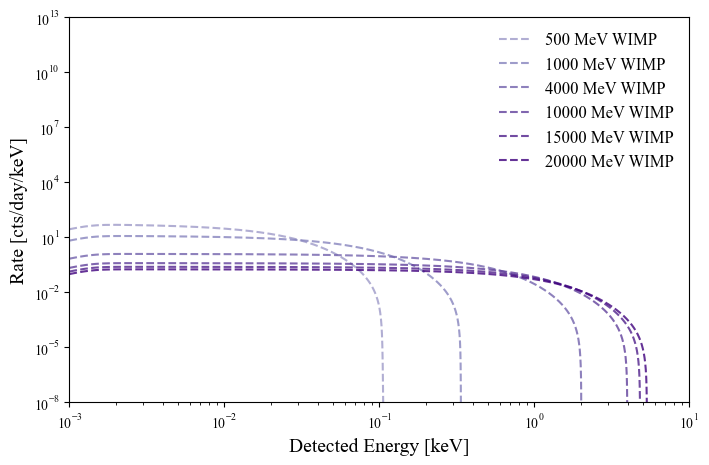

In [12]:
# plot WIMPs:

sigma0 = 1e-37 # cm2
he_gain = 0.15
tm = 'He'

per_device_threshold = 0.8e-3
threshold = n_devices*per_device_threshold

m_dms = np.array([0.5,1,4,10,15,20])

# WIMP shapes:
drdefunction = [ lambda x,m: darklim.sensitivity.drde_wimp_obs( x, m, sigma0, tm, he_gain ) for m in m_dms ]

wimpe_low, wimpe_high = 1e-3, 10
wimp_en_interp = np.geomspace(wimpe_low,wimpe_high, num=10000)

plot_wimp=True

fig, ax = plt.subplots(1,figsize=(8,5))

n_lines = len(m_dms)
#cmaps = ['Blues','Oranges','Greens']
cmap = matplotlib.colormaps['Purples']
wimpcolors = cmap(np.linspace(0.5, 1, n_lines))

###################################################################

# plot WIMP shapes for comparison - note these have He gain and energy resolution for a single device applied
#label_ys = np.geomspace(1e4,1e6,num=3)
if plot_wimp:
    for ii, mass in enumerate(m_dms):
        init_rate = drdefunction[ii](wimp_en_interp,mass)    
        smeared_rate = darklim.limit.gauss_smear(wimp_en_interp, init_rate, np.sqrt(n_devices)*energy_res)
        plt.plot(wimp_en_interp,smeared_rate*he_mass,
                 ls='--', color=wimpcolors[ii],alpha=0.8,
                 label='{:.0f} MeV WIMP'.format(mass*1000))

        #ax.text(0.25e-3,label_ys[ii],r'{:.0f} MeV/$c^2$'.format(m_dms[len(m_dms)-(ii+1)]*1000),
        #        fontsize=10,color=wimpcolors[len(m_dms)-(ii+1)],alpha=0.8)

    #ax.text(0.25e-3,1e7,r'WIMP Mass at $\sigma = 10^{-37}$ cm$^2$:',
    #            fontsize=10,color=wimpcolors[2],alpha=0.8)
    
ax.set_xlim(1e-3,10)
ax.set_xscale('log')
ax.set_ylim(1e-8,1e13)
ax.set_yscale('log')
ax.legend(loc='upper right', frameon=False,ncol=1,fontsize=12)
ax.set_xlabel('Detected Energy [keV]',fontsize=14)
ax.set_ylabel('Rate [cts/day/keV]',fontsize=14)



In [6]:
# load LEE templates:

detectors = ['4-1cm2','4-1cm2-thin','4-1cm2-thin-0.1xLEE']
#detectors = ['4-1cm2-thin','4-1cm2-thin','4-1cm2-thin']
#thresholds = np.array([0.6,0.7,0.8])*1e-3

thresholds = np.ones(len(detectors))*0.8e-3

hdict = {}

# rate printouts:
#lower = per_device_threshold*n_devices
upper = 200e-3

texpo = 50

for i,d in enumerate(detectors):
    print('')
    hdict[d+str(i)] = load_template(detector=d,window='var',part='wpart',thres=thresholds[i])#per_device_threshold)
    
    lower = thresholds[i]*n_devices
    
    print( '{:s} rate {:0.2f}-{:0.2f} eV:\t {:0.4e} cts/day'.format( d, lower*1000, upper*1000, hist_integral(hdict[d+str(i)],lower,upper,option='w') ) )
    print('  cts in {:0.1f} days: {:0.4e} cts'.format(texpo,texpo*hist_integral(hdict[d+str(i)],lower,upper,option='w') ) )
    

print('\n10 DRU bkg rate = ',(upper-lower)*10*1.1e-3/he_gain,'cts/day')
print('10 DRU bkg cts = ',texpo*(upper-lower)*10*1.1e-3/he_gain,'cts')

#ht = load_template(detector='4-1cm2',window='var',part='wpart',thres=per_device_threshold)
#ht_thin = load_template(detector='4-1cm2-thin',window='var',part='wpart',thres=per_device_threshold)
#ht_thin_low = load_template(detector='4-1cm2-thin-0.1xLEE',window='var',part='wpart',thres=per_device_threshold)


#for d in detectors:
#    print(hdict[d].histogram[0:10])



4-1cm2 rate 3.20-200.00 eV:	 2.1524e-02 cts/day
  cts in 50.0 days: 1.0762e+00 cts

4-1cm2-thin rate 3.20-200.00 eV:	 1.3452e-03 cts/day
  cts in 50.0 days: 6.7262e-02 cts

4-1cm2-thin-0.1xLEE rate 3.20-200.00 eV:	 1.3452e-07 cts/day
  cts in 50.0 days: 6.7262e-06 cts

10 DRU bkg rate =  0.014432000000000002 cts/day
10 DRU bkg cts =  0.7216000000000001 cts


h1 rate 3.20-200.00 eV:	 2.7964e-01 cts/day
h2 rate 3.20-200.00 eV:	 1.7477e-06 cts/day
done.


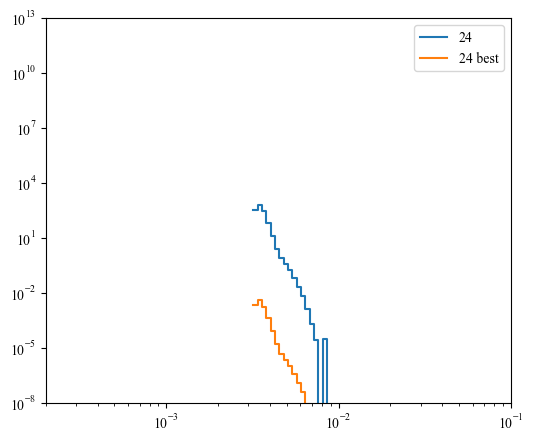

In [11]:

fig, ax = plt.subplots(1,figsize=(6,5))
d = '4-1cm2-thin'
thres = 0.8e-3
h1 = load_template(detector='24-1cm2',window='var',part='wpart',thres=thres,src='test')
h2 = load_template(detector='24-1cm2-thin-0.1xLEE',window='var',part='wpart',thres=thres,src='test')

h1.plot(label='24')
h2.plot(label='24 best')

ax.set_xlim(0.2e-3,100e-3)
ax.set_xscale('log')
ax.set_ylim(1e-8,1e13)
ax.set_yscale('log')
ax.legend()

upper = 200e-3
lower = thres*n_devices
print( 'h1 rate {:0.2f}-{:0.2f} eV:\t {:0.4e} cts/day'.format( lower*1000, upper*1000, hist_integral(h1,lower,upper,option='w') ) )
print( 'h2 rate {:0.2f}-{:0.2f} eV:\t {:0.4e} cts/day'.format( lower*1000, upper*1000, hist_integral(h2,lower,upper,option='w') ) )

print('done.')


In [7]:
# make WIMP shapes

m_dms = np.array([0.05,0.1,0.5])

# WIMP shapes:
drdefunction = [ lambda x,m: darklim.sensitivity.drde_wimp_obs( x, m, sigma0, tm, he_gain ) for m in m_dms ]

wimpe_low, wimpe_high = 5e-5, 1.0
wimp_en_interp = np.geomspace(wimpe_low,wimpe_high, num=100000)


done.


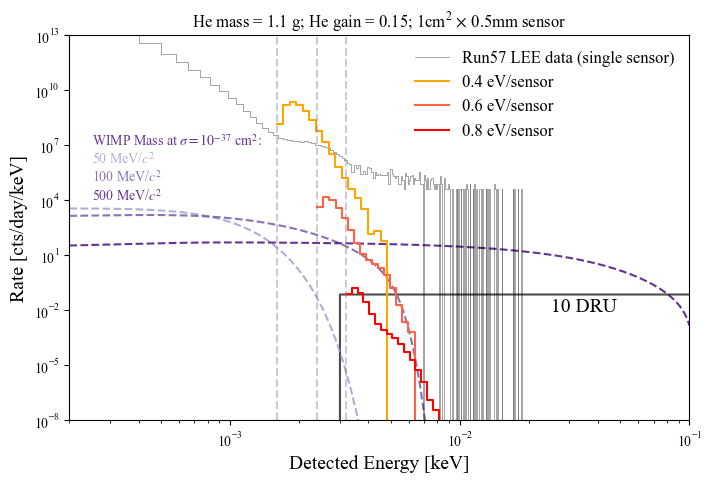

In [21]:
### plot with same senor, varying threshld

plot_wimp=True

fig, ax = plt.subplots(1,figsize=(8,5))

n_lines = len(m_dms)
#cmaps = ['Blues','Oranges','Greens']
cmap = matplotlib.colormaps['Purples']
wimpcolors = cmap(np.linspace(0.5, 1, n_lines))

###################################################################

# plot WIMP shapes for comparison - note these have He gain and energy resolution for a single device applied
label_ys = np.geomspace(1e4,1e6,num=3)
if plot_wimp:
    for ii, mass in enumerate(m_dms):
        init_rate = drdefunction[ii](wimp_en_interp,mass)    
        smeared_rate = darklim.limit.gauss_smear(wimp_en_interp, init_rate, np.sqrt(n_devices)*energy_res)
        plt.plot(wimp_en_interp,smeared_rate*he_mass,
                 ls='--', color=wimpcolors[ii],alpha=0.8)#,
                 #label='{:.0f} MeV WIMP'.format(mass*1000))

        ax.text(0.25e-3,label_ys[ii],r'{:.0f} MeV/$c^2$'.format(m_dms[len(m_dms)-(ii+1)]*1000),
                fontsize=10,color=wimpcolors[len(m_dms)-(ii+1)],alpha=0.8)

    ax.text(0.25e-3,1e7,r'WIMP Mass at $\sigma = 10^{-37}$ cm$^2$:',
                fontsize=10,color=wimpcolors[2],alpha=0.8)
    

#plt.plot(en_interp,power_pdf(en_interp),lw=1.5,color='tomato',
#         label='Run 47 Power Law LEE;\n {:.0f} cts/day in [{:.2f},{:.0f}] eV'.format(power_rate,threshold*1e3,e_high*1e3))

#plt.plot(en_interp,expo_pdf(en_interp),lw=1.5,color='steelblue',
#         label='Run 57 Exponential LEE (shared+singles);\n {:.0f} cts/day in [{:.2f},{:.0f}] eV'.format(expo_rate,threshold*1e3,e_high*1e3))


h.plot(scale_histogram_by=1,lw=0.5,color='black',alpha=0.5,label='Run57 LEE data (single sensor)')

#r'1cm$^2$ x 0.5mm; {:0.1f} eV/sensor'.format(1000*per_device_threshold)

colors = ['orange','tomato','red']
#labels = [r'1cm$^2$ $\times$ 1mm',
#          r'1cm$^2$ $\times$ 0.5mm',
#          r'1cm$^2$ $\times$ 0.5mm;  $10\times$ lower LEE']
labels = [r'0.4 eV/sensor',
          r'0.6 eV/sensor',
          r'0.8 eV/sensor']
for i,d in enumerate(detectors):
    hdict[d+str(i)].plot(lw=1.5,label=labels[i],color=colors[i])
    ax.axvline(thresholds[i]*n_devices,ls='--',color='grey',alpha=0.4)

#ht.plot(lw=1,label=r'1cm$^2$ x 1mm; {:0.1f} eV/sensor'.format(1000*per_device_threshold),color='orange')
#ht_thin.plot(lw=1,label=,color='tomato')
#ht_thin_low.plot(lw=1,label=r'1cm$^2$ x 0.5mm; 10% LEE; {:0.1f} eV/sensor'.format(1000*per_device_threshold),color='red')




# particle bkgs:
es = np.geomspace(0.2e-3,100e-3,num=1000)
plt.plot( es, np.heaviside(es-20e-3*he_gain,1)*10*1.1e-3/he_gain, ls='-',color='black',alpha=0.7,zorder=1)
#ax.axhline(10*1.1e-3/0.15,ls='-',color='black',alpha=0.7,zorder=1) # 1 DRU line
ax.text(2.5e-2,8*1.1e-3,'10 DRU',fontsize=14)


ax.set_xlim(0.2e-3,100e-3)
ax.set_xscale('log')
ax.set_ylim(1e-8,1e13)
ax.set_yscale('log')
#ax.legend(loc='upper right', title='{:d} Total Devices\nCoincidence Level:'.format(m), frameon=False,ncol=1,fontsize=13,title_fontsize=15)
#ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.legend(loc='upper right', frameon=False,ncol=1,fontsize=12)
ax.set_xlabel('Detected Energy [keV]',fontsize=14)
ax.set_ylabel('Rate [cts/day/keV]',fontsize=14)
#ax.set_title(r'Single Sensor Spectra; He gain = {:0.2f}, $\sigma_E=${:0.0f} meV'.format(he_gain,energy_res*1e6))
#ax.set_title(r'He mass = 1.1 g; He gain = {:0.2f}; $\sigma_E=${:0.0f} meV; {:0.1f} eV/sensor'.format(he_gain,energy_res*1e6,1000*per_device_threshold))

#ax.set_title(r'He mass = 1.1 g; He gain = {:0.2f}; 1cm$^2$ $\times$ 0.5mm;  $10\times$ lower LEE sensor'.format(he_gain))

ax.set_title(r'He mass = 1.1 g; He gain = {:0.2f}; 1cm$^2$ $\times$ 0.5mm sensor'.format(he_gain))

#plt.savefig('./CDR_plots/spectrum_{:0.1f}eV.png'.format(1000*per_device_threshold),facecolor='white',bbox_inches='tight',dpi=500)
#plt.savefig('./CDR_plots/spectrum_varthresold_thin.png',facecolor='white',bbox_inches='tight',dpi=500)
print('done.')


done.


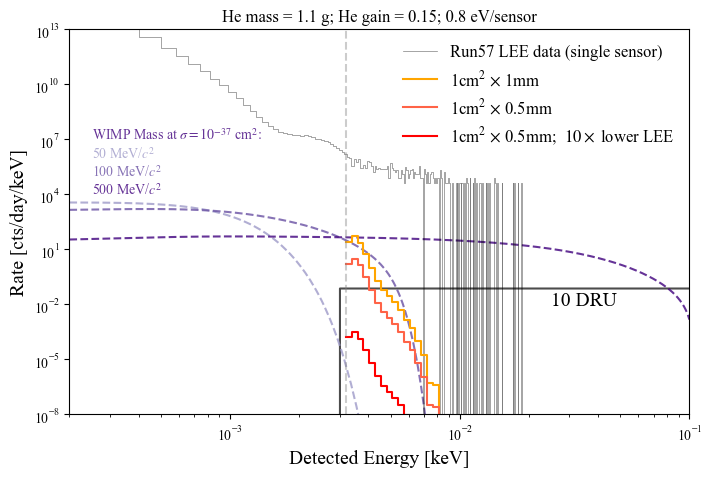

In [8]:
### background plot in keV

plot_wimp=True

fig, ax = plt.subplots(1,figsize=(8,5))

n_lines = len(m_dms)
#cmaps = ['Blues','Oranges','Greens']
cmap = matplotlib.colormaps['Purples']
wimpcolors = cmap(np.linspace(0.5, 1, n_lines))

###################################################################

# plot WIMP shapes for comparison - note these have He gain and energy resolution for a single device applied
label_ys = np.geomspace(1e4,1e6,num=3)
if plot_wimp:
    for ii, mass in enumerate(m_dms):
        init_rate = drdefunction[ii](wimp_en_interp,mass)    
        smeared_rate = darklim.limit.gauss_smear(wimp_en_interp, init_rate, np.sqrt(n_devices)*energy_res)
        plt.plot(wimp_en_interp,smeared_rate*he_mass,
                 ls='--', color=wimpcolors[ii],alpha=0.8)#,
                 #label='{:.0f} MeV WIMP'.format(mass*1000))

        ax.text(0.25e-3,label_ys[ii],r'{:.0f} MeV/$c^2$'.format(m_dms[len(m_dms)-(ii+1)]*1000),
                fontsize=10,color=wimpcolors[len(m_dms)-(ii+1)],alpha=0.8)

    ax.text(0.25e-3,1e7,r'WIMP Mass at $\sigma = 10^{-37}$ cm$^2$:',
                fontsize=10,color=wimpcolors[2],alpha=0.8)
    

#plt.plot(en_interp,power_pdf(en_interp),lw=1.5,color='tomato',
#         label='Run 47 Power Law LEE;\n {:.0f} cts/day in [{:.2f},{:.0f}] eV'.format(power_rate,threshold*1e3,e_high*1e3))

#plt.plot(en_interp,expo_pdf(en_interp),lw=1.5,color='steelblue',
#         label='Run 57 Exponential LEE (shared+singles);\n {:.0f} cts/day in [{:.2f},{:.0f}] eV'.format(expo_rate,threshold*1e3,e_high*1e3))


h.plot(scale_histogram_by=1,lw=0.5,color='black',alpha=0.5,label='Run57 LEE data (single sensor)')

#r'1cm$^2$ x 0.5mm; {:0.1f} eV/sensor'.format(1000*per_device_threshold)

colors = ['orange','tomato','red']
labels = [r'1cm$^2$ $\times$ 1mm',
          r'1cm$^2$ $\times$ 0.5mm',
          r'1cm$^2$ $\times$ 0.5mm;  $10\times$ lower LEE']
for i,d in enumerate(detectors):
    hdict[d+str(i)].plot(lw=1.5,label=labels[i],color=colors[i])

#ht.plot(lw=1,label=r'1cm$^2$ x 1mm; {:0.1f} eV/sensor'.format(1000*per_device_threshold),color='orange')
#ht_thin.plot(lw=1,label=,color='tomato')
#ht_thin_low.plot(lw=1,label=r'1cm$^2$ x 0.5mm; 10% LEE; {:0.1f} eV/sensor'.format(1000*per_device_threshold),color='red')


ax.axvline(threshold,ls='--',color='grey',alpha=0.4)

# particle bkgs:
es = np.geomspace(0.2e-3,100e-3,num=1000)
plt.plot( es, np.heaviside(es-20e-3*he_gain,1)*10*1.1e-3/he_gain, ls='-',color='black',alpha=0.7,zorder=1)
#ax.axhline(10*1.1e-3/0.15,ls='-',color='black',alpha=0.7,zorder=1) # 1 DRU line
ax.text(2.5e-2,8*1.1e-3,'10 DRU',fontsize=14)


ax.set_xlim(0.2e-3,100e-3)
ax.set_xscale('log')
ax.set_ylim(1e-8,1e13)
ax.set_yscale('log')
#ax.legend(loc='upper right', title='{:d} Total Devices\nCoincidence Level:'.format(m), frameon=False,ncol=1,fontsize=13,title_fontsize=15)
#ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.legend(loc='upper right', frameon=False,ncol=1,fontsize=12)
ax.set_xlabel('Detected Energy [keV]',fontsize=14)
ax.set_ylabel('Rate [cts/day/keV]',fontsize=14)
#ax.set_title(r'Single Sensor Spectra; He gain = {:0.2f}, $\sigma_E=${:0.0f} meV'.format(he_gain,energy_res*1e6))
#ax.set_title(r'He mass = 1.1 g; He gain = {:0.2f}; $\sigma_E=${:0.0f} meV; {:0.1f} eV/sensor'.format(he_gain,energy_res*1e6,1000*per_device_threshold))
ax.set_title(r'He mass = 1.1 g; He gain = {:0.2f}; {:0.1f} eV/sensor'.format(he_gain,1000*per_device_threshold))

#plt.savefig('./CDR_plots/spectrum_{:0.1f}eV.png'.format(1000*per_device_threshold),facecolor='white',bbox_inches='tight',dpi=500)
#plt.savefig('./CDR_plots/spectrum_varthresold_0.8eV.png',facecolor='white',bbox_inches='tight',dpi=500)
print('done.')


done.


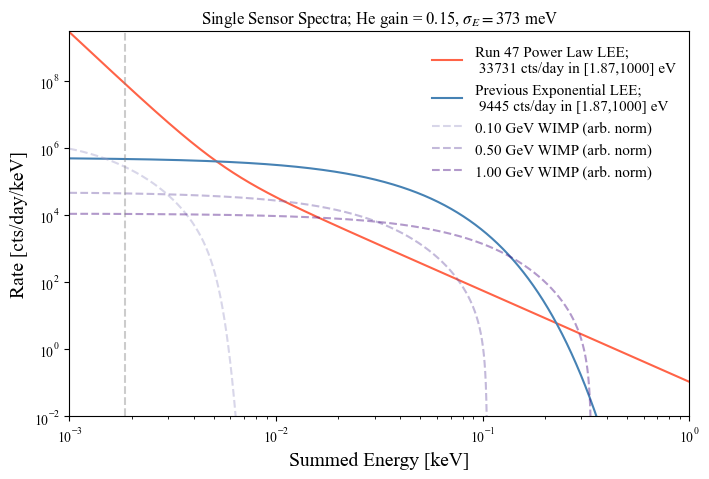

In [9]:
### don't delete... older vesrion of plot

# two LEEs:
power_pdf = lambda x: power_bkgd(x,1.4e-8, 5.77)+power_bkgd(x,0.107, 2.72)
expo_pdf = lambda x: darklim.sensitivity.n_fold_lee(x,m=1,n=1,e0=0.020,R=0.12,w=100e-6)

e_low, e_high = 1e-3, 1.0
en_interp = np.geomspace(e_low,e_high, num=10000)

power_rate = pdf_integral(power_pdf,threshold,e_high,10000)
expo_rate = pdf_integral(expo_pdf,threshold,e_high,10000)

# WIMP shapes:
drdefunction = [ lambda x,m: darklim.sensitivity.drde_wimp_obs( x, m, sigma0, tm, he_gain ) for m in m_dms ]

wimpe_low, wimpe_high = 1e-4, 1.0
wimp_en_interp = np.geomspace(wimpe_low,wimpe_high, num=10000)

#####
fig, ax = plt.subplots(1,figsize=(8,5))


n_lines = len(m_dms)
#cmaps = ['Blues','Oranges','Greens']
cmap = matplotlib.colormaps['Purples']
wimpcolors = cmap(np.linspace(0.5, 1, n_lines))



###################################################################

plt.plot(en_interp,power_pdf(en_interp),lw=1.5,color='tomato',
         label='Run 47 Power Law LEE;\n {:.0f} cts/day in [{:.2f},{:.0f}] eV'.format(power_rate,threshold*1e3,e_high*1e3))

plt.plot(en_interp,expo_pdf(en_interp),lw=1.5,color='steelblue',
         label='Previous Exponential LEE;\n {:.0f} cts/day in [{:.2f},{:.0f}] eV'.format(expo_rate,threshold*1e3,e_high*1e3))

# plot WIMP shapes for comparison - note these have He gain and energy resolution for a single device applied
for ii, mass in enumerate(m_dms):
    init_rate = drdefunction[ii](wimp_en_interp,mass)    
    smeared_rate = darklim.limit.gauss_smear(wimp_en_interp, init_rate, np.sqrt(n_devices)*energy_res)
    #plt.plot(en_interp,init_rate)
    plt.plot(wimp_en_interp,smeared_rate,
             ls='--', color=wimpcolors[ii],alpha=0.4,
             label='{:.2f} GeV WIMP (arb. norm)'.format(mass))

ax.axvline(threshold,ls='--',color='grey',alpha=0.4)

ax.set_xlim(e_low,e_high)
ax.set_xscale('log')
ax.set_ylim(1e-2,None)
ax.set_yscale('log')
#ax.legend(loc='upper right', title='{:d} Total Devices\nCoincidence Level:'.format(m), frameon=False,ncol=1,fontsize=13,title_fontsize=15)
#ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.legend(loc='upper right', frameon=False,ncol=1,fontsize=11)
ax.set_xlabel('Summed Energy [keV]',fontsize=14)
ax.set_ylabel('Rate [cts/day/keV]',fontsize=14)
ax.set_title(r'Single Sensor Spectra; He gain = 0.15, $\sigma_E=373$ meV')
print('done.')


m =  0.1
5539.229100502662
m =  0.5
7080.513398517891
m =  1.0
5391.908251843492


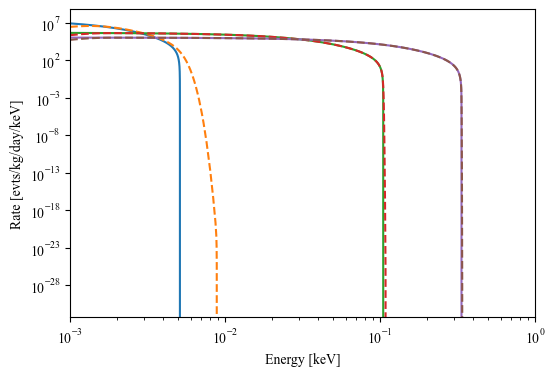

In [22]:
# test making the drdefunction as in run_sim:
n_devices = 1
sigma0 = 1e-36 # cm2
he_gain = 0.15
tm = 'He'
m_dms = np.array([0.1,0.5,1])

drdefunction = [ lambda x,m: darklim.sensitivity.drde_wimp_obs( x, m, sigma0, tm, he_gain ) for m in m_dms ]
elow = threshold
ehigh = 10
en_interp = np.geomspace(e_low, e_high, int(1e5))

fig, ax = plt.subplots(1,figsize=(6,4))
for ii, mass in enumerate(m_dms):
    print('m = ',mass)
    
    #obs_dm_func = lambda x: darklim.sensitivity.drde_wimp_obs( x, mass, sigma0, tm, he_gain )
    #init_rate = obs_dm_func(en_interp)
    
    init_rate = drdefunction[ii](en_interp,mass)
    
    smeared_rate = darklim.limit.gauss_smear(en_interp, init_rate, np.sqrt(n_devices)*energy_res)
    
    plt.plot(en_interp,init_rate)
    plt.plot(en_interp,smeared_rate,ls='--')
    
    print(np.trapz(init_rate,x=en_interp))

ax.set_ylabel('Rate [evts/kg/day/keV]')
ax.set_xlabel('Energy [keV]')
ax.set_xlim(e_low,e_high)
ax.set_xscale('log')
ax.set_yscale('log')

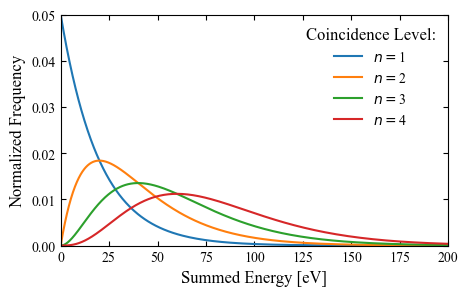

In [18]:
fig, ax = plt.subplots(1,figsize=(5,3))

lam = 1/20
ks = np.arange(1,5)
x = np.geomspace(1e-3,1e3,1000)

for k in ks:

    dist = stats.erlang.pdf(x,a=k,loc=0,scale=1/lam)
    dist2 = stats.expon.pdf(x,loc=0,scale=1/lam)

    plt.plot(x, dist,label=r'$n=$'+'{:d}'.format(k))
    
#plt.plot(x, dist2,'r--',label='Expo. Dist')
ax.set_xlim(0,200)
ax.set_ylim(0,0.05)
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend(loc='upper right',frameon=False,title='Coincidence Level:',title_fontsize=12)
ax.set_xlabel('Summed Energy [eV]',fontsize=12)
ax.set_ylabel('Normalized Frequency',fontsize=12)

plt.savefig('./pretty_plots/erlang.png',facecolor='white',bbox_inches='tight')

In [3]:
# generate ntoys
e_low = 1e-6
e_high = 10
npts = 1000

ntoys = 1000000

lam = 1/0.020
pdf = lambda x: stats.expon.pdf(x,loc=0,scale=1/lam)

energy_res = 0.373e-3 # energy resolution in keV
sigma = 50
threshold = sigma*energy_res
print('threshold = {:0.3e} keV'.format(threshold))

#evts_sim = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )

threshold = 1.865e-02 keV


In [34]:
# generate toys from m devices with n-fold coincidence

sum_all_energy = False


devices = np.array([2,3,4])

summed_energy = {}

for i,m in enumerate(devices):
    
    # simulate events in all devices:
    evts = np.zeros((m,ntoys))
    for d in range(m):
        evts[d,:] = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )
    
    #print( evts[0,:10] )
    evts[np.where(evts<threshold)] = 0 # sets events below threshold to zero
    #print( evts[0,:10] )
    summed_energy[m] = np.sum(evts,axis=0) # sum energy accross devices
    
    #coinc = np.arange(2,m+1)
    #print('{} devices. coinc levels considered are '.format(m),coinc)
    
    #for j,n in enumerate(coinc):
    #    print('coinc level is ',n)
    #    
    #    # apply threshold to the first n channels
    #    for d in range(n):
    #        evts[d,:]
print('done.')

done.


Text(0.5, 0, 'Summed Energy [keV]')

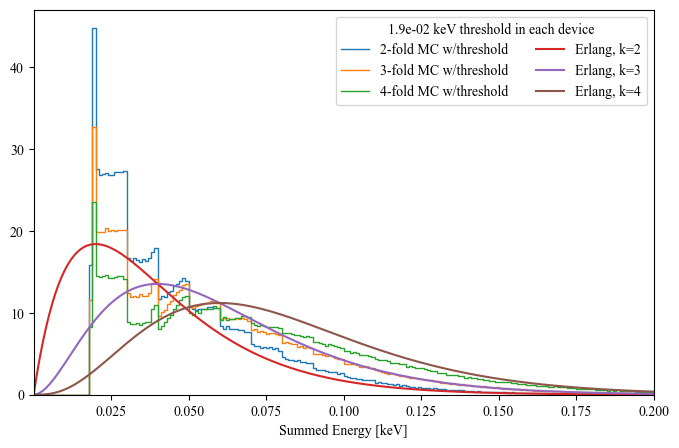

In [35]:
# histogram the simulated toys
fig, ax = plt.subplots(1,figsize=(8,5))

for i,m in enumerate(devices):
    h = Hist1d(summed_energy[m],bins=10000,range=(e_low,e_high))
    bw = h.bin_centers[1]-h.bin_centers[0]
    h.plot(scale_histogram_by=1/bw,lw=1,label='{}-fold MC w/threshold'.format(m),normed=True)

#x = np.geomspace(e_low,e_high,10000)
x = np.linspace(e_low,e_high,10000)
for k in devices:
    dist = stats.erlang.pdf(x,a=k,loc=0,scale=1/lam)
    plt.plot(x, dist/np.trapz(dist, x=x),label='Erlang, k={:d}'.format(k))
        

ax.set_xlim(e_low,0.2)
#ax.set_xscale('log')
ax.set_ylim(0,None)
ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.set_xlabel('Summed Energy [keV]')

In [25]:
test = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )
print(test)
test[np.where(test<0.02)] = 0
print(test)

[0.01814909 0.08861029 0.02425482 ... 0.00364906 0.00120441 0.01921873]
[0.         0.08861029 0.02425482 ... 0.         0.         0.        ]


In [24]:
test

array([0.06928629, 0.        , 0.        , ..., 0.        , 0.        ,
       0.        ])

10000


Text(0.5, 0, 'Summed Energy [keV]')

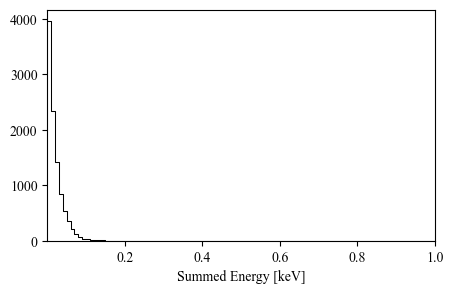

In [6]:
# histogram the simulated toys
fig, ax = plt.subplots(1,figsize=(5,3))

h = Hist1d(evts_sim,bins=npts,range=(e_low,e_high))
h.plot(color='black',lw=0.75)

print(h.n)

ax.set_xlim(e_low,1)
#ax.set_xscale('log')
ax.set_ylim(0,None)
#ax.legend(loc='upper right')
ax.set_xlabel('Summed Energy [keV]')

In [4]:
# Detector info setup

#n_devices = 4
#coinc = 2
#window = 100e-6 # s

mass_det = 0.00115 # mass in kg
time_elapsed = 1000 # days
efficiency = 1.0

tm = 'He' # target name

energy_res = 0.373e-3 # energy resolution in keV
#threshold = coinc*5*energy_res

print('detector mass is {} kg = {} g'.format(mass_det,mass_det*1000))
print('run time is {} days'.format(time_elapsed))
print('exposure is {} kg-days'.format(mass_det*time_elapsed))
#print('threshold = {:0.3f} eV'.format(threshold*1000))
#print('assuming {:d}-fold coincidence amongst {:d} devices in a {:0.1f} microsecond window'.format(coinc,n_devices,window/1e-6))

detector mass is 0.00115 kg = 1.15 g
run time is 1000 days
exposure is 1.15 kg-days


In [ ]:
SE = darklim.sensitivity.SensEst(mass_det, time_elapsed, eff=efficiency, tm=tm)

SE.reset_sim()
#SE.add_flat_bkgd(1) # flat background of 1 DRU
#SE.add_nfold_lee_bkgd(m=4,n=2,w=window)
SE.add_nfold_lee_bkgd(m=n_devices,n=coinc,w=window)

In [ ]:
# p-values to demonstrate the sf and isf functions:
p_sig = np.zeros(6) # p values
sigma = np.zeros(6) # sigmas
for sig in range(1,6):
    p_sig[sig-1] = stats.norm.sf(sig)
    sigma[sig-1] = stats.norm.isf(p_sig[sig-1])
    print('p-value for {:d} sigma is {:0.5e}'.format(sig,p_sig[sig-1]))
    print(' ->check that sigma is {:0.2f}\n'.format(sigma[sig-1]))